In [1]:
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import json
import os

# 1. Khai báo danh sách file JSON và thư mục đầu ra
json_files = [
    "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/1_to_250.json",
    "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/251_to_350.json",
    "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/351_to_500.json",
    "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/751_to_800.json",
    "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/801_to_900.json",
    "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/901_to_1000.json"
]

output_dir = "labels"  # Thư mục lưu annotation
os.makedirs(output_dir, exist_ok=True)

# 2. Ánh xạ tên nhãn sang Class ID
class_mapping = {
    "Bo_den": 0,
    "Bo_den_thon": 1,
    "Sau_duc_than": 2
}

# 3. Lặp qua từng file JSON
for json_file in json_files:
    if not os.path.exists(json_file):
        print(f"Cảnh báo: Không tìm thấy file '{json_file}'. Bỏ qua.")
        continue

    print(f"Đang xử lý file: {json_file}...")
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    for item in data:
        # Tên file trên Label Studio (ví dụ: "3bb7a61a-raw_pic_251.jpg")
        uploaded_filename = item['file_upload']

        # Cắt bỏ phần hash để lấy đúng tên ảnh gốc (ví dụ: "raw_pic_251.jpg")
        if '-' in uploaded_filename:
            original_filename = uploaded_filename.split('-', 1)[1]
        else:
            original_filename = uploaded_filename

        # Đổi đuôi .jpg thành .txt
        txt_filename = os.path.splitext(original_filename)[0] + ".txt"
        txt_filepath = os.path.join(output_dir, txt_filename)

        annotations = item.get('annotations', [])
        if not annotations:
            continue

        results = annotations[0].get('result', [])
        yolo_lines = []

        # 4. Trích xuất và chuyển đổi tọa độ bounding box
        for res in results:
            if res.get('type') != 'rectanglelabels':
                continue

            box_data = res['value']
            label_name = box_data['rectanglelabels'][0]
            class_id = class_mapping.get(label_name, -1)

            if class_id == -1:
                continue

            # Lấy tỷ lệ phần trăm tọa độ
            x_pct = box_data['x']
            y_pct = box_data['y']
            w_pct = box_data['width']
            h_pct = box_data['height']

            # Chuyển đổi sang format YOLO (center_x, center_y, width, height từ 0-1)
            x_center = (x_pct + w_pct / 2.0) / 100.0
            y_center = (y_pct + h_pct / 2.0) / 100.0
            w_norm = w_pct / 100.0
            h_norm = h_pct / 100.0

            line = f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"
            yolo_lines.append(line)

        # 5. Ghi dữ liệu ra file .txt
        if yolo_lines:
            with open(txt_filepath, 'w') as out_f:
                out_f.write("\n".join(yolo_lines))

print(f"\nHoàn tất! Toàn bộ file .txt đã được lưu tại thư mục '{output_dir}/'.")

Đang xử lý file: /kaggle/input/datasets/anhphmduy/bugs-in-rice-field/1_to_250.json...
Đang xử lý file: /kaggle/input/datasets/anhphmduy/bugs-in-rice-field/251_to_350.json...
Đang xử lý file: /kaggle/input/datasets/anhphmduy/bugs-in-rice-field/351_to_500.json...
Đang xử lý file: /kaggle/input/datasets/anhphmduy/bugs-in-rice-field/751_to_800.json...
Đang xử lý file: /kaggle/input/datasets/anhphmduy/bugs-in-rice-field/801_to_900.json...
Đang xử lý file: /kaggle/input/datasets/anhphmduy/bugs-in-rice-field/901_to_1000.json...

Hoàn tất! Toàn bộ file .txt đã được lưu tại thư mục 'labels/'.


In [3]:
import json
import os
import re
import urllib.parse  # Thư viện mới để giải mã các ký tự %20, %5C...

# 1. Khai báo đường dẫn
json_file = "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/501_to_750.json" 
output_dir = "labels"
os.makedirs(output_dir, exist_ok=True)

# 2. Ánh xạ Class ID
class_mapping = {
    "bo_den": 0,
    "bo_den_thon": 1,
    "sau_duc_than": 2
}

print(f"⏳ Đang xử lý file JSON: {os.path.basename(json_file)} ...")

try:
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    parsed_count = 0
    empty_count = 0

    # 3. Quét từng mục trong JSON
    for task in data:
        if 'file_upload' in task:
            raw_filename = task['file_upload']
        elif 'data' in task and 'image' in task['data']:
            raw_filename = os.path.basename(task['data']['image'])
        else:
            continue

        # BƯỚC XỬ LÝ TÊN FILE MỚI:
        # 3.1. Cắt bỏ chuỗi hash ngẫu nhiên của Label Studio ở đầu file
        if '-' in raw_filename:
            raw_filename = raw_filename.split('-', 1)[1]

        # 3.2. Giải mã URL (Ví dụ: "Training%20AI%5Craw_pic%20%28503%29.jpg" -> "Training AI\raw_pic (503).jpg")
        decoded_filename = urllib.parse.unquote(raw_filename)

        # 3.3. Lấy tên file gốc, bỏ đi tên thư mục (Đổi \ thành / để chạy đúng trên cả Windows/Linux)
        basename = os.path.basename(decoded_filename.replace('\\', '/')) 
        # Kết quả lúc này: "raw_pic (503).jpg"

        # 3.4. Dùng Regex để đổi " (503)" thành "_503"
        # Tìm khoảng trắng + dấu ngoặc đơn chứa số bên trong, rồi thay bằng dấu gạch dưới + số
        clean_basename = re.sub(r'\s*(.∗?)(.*?)', r'_\1', basename)
        # Kết quả lúc này: "raw_pic_503.jpg"

        # 3.5. Đổi đuôi ảnh thành .txt
        txt_filename = os.path.splitext(clean_basename)[0] + ".txt"
        txt_filepath = os.path.join(output_dir, txt_filename)

        # Lấy danh sách hộp dự đoán
        annotations = task.get('annotations', [])
        if not annotations:
            continue
            
        results = annotations[0].get('result', [])
        if not results:
            empty_count += 1
            continue

        yolo_lines = []

        # 4. Trích xuất và tính toán tọa độ
        for res in results:
            if res.get('type') != 'rectanglelabels':
                continue
                
            val = res.get('value', {})
            labels = val.get('rectanglelabels', [])
            if not labels:
                continue
                
            label_name = labels[0].lower()
            if label_name not in class_mapping:
                print(f"⚠️ Cảnh báo: Nhãn lạ '{label_name}' không có trong từ điển.")
                continue
                
            class_id = class_mapping[label_name]

            x_pct = val['x']
            y_pct = val['y']
            w_pct = val['width']
            h_pct = val['height']

            w = w_pct / 100.0
            h = h_pct / 100.0
            cx = (x_pct / 100.0) + (w / 2.0)
            cy = (y_pct / 100.0) + (h / 2.0)

            cx, cy = max(0, min(1, cx)), max(0, min(1, cy))
            w, h = max(0, min(1, w)), max(0, min(1, h))

            yolo_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        # 5. Lưu xuống file .txt
        if yolo_lines:
            with open(txt_filepath, 'w') as out_f:
                out_f.write('\n'.join(yolo_lines))
            parsed_count += 1

    print("✅ HOÀN TẤT XỬ LÝ!")
    print(f"   - Đã tạo thành công {parsed_count} file .txt cho các ảnh có nhãn.")
    print(f"   - Bỏ qua {empty_count} ảnh không có vật thể (Background).")

except FileNotFoundError:
    print(f"❌ LỖI: Không tìm thấy file JSON ở đường dẫn: {json_file}")

⏳ Đang xử lý file JSON: 501_to_750.json ...
✅ HOÀN TẤT XỬ LÝ!
   - Đã tạo thành công 244 file .txt cho các ảnh có nhãn.
   - Bỏ qua 6 ảnh không có vật thể (Background).


In [4]:
# --- Ô CODE 1: KHỞI TẠO ---
import os
import re
import shutil
import random
import yaml
import cv2
import matplotlib.pyplot as plt

# 1. Khai báo đường dẫn
IMAGE_DIR = "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/dataset_raw_1000"
LABEL_DIR = "labels" # Thư mục chứa các file .txt bạn đã trích xuất từ JSON
OUTPUT_DIR = "yolo_dataset"

# 2. Khai báo Classes
CLASS_MAPPING = {
    0: "Bo_den",
    1: "Bo_den_thon",
    2: "Sau_duc_than"
}

print("✅ Đã tải thư viện và cấu hình đường dẫn thành công!")

✅ Đã tải thư viện và cấu hình đường dẫn thành công!


In [5]:
import os
import shutil
import random
import re

# --- 1. Cấu hình đường dẫn ---
IMAGE_DIR = "/kaggle/input/datasets/anhphmduy/bugs-in-rice-field/dataset_raw_1000/dataset_raw_1000"
LABEL_DIR = "labels"         
OUTPUT_DIR = "yolo_dataset"  

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# TẠO THÊM THƯ MỤC TEST
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'labels'), exist_ok=True)

# --- 2. Tạo bộ từ điển nhãn ---
label_files = [f for f in os.listdir(LABEL_DIR) if f.endswith('.txt')]
label_dict = {}
for lf in label_files:
    nums = re.findall(r'\d+', lf)
    if nums:
        label_dict[nums[-1]] = lf 

# --- 3. Quét toàn bộ ảnh (KHÔNG LỌC) ---
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.png', '.jpeg'))]
all_pairs = []
background_count = 0

for img in image_files:
    nums = re.findall(r'\d+', img)
    if nums and nums[-1] in label_dict:
        all_pairs.append((img, label_dict[nums[-1]]))
    else:
        all_pairs.append((img, None))
        background_count += 1

print(f"📊 THỐNG KÊ DỮ LIỆU:")
print(f" - Tổng số ảnh đưa vào: {len(all_pairs)}")
print(f" - Số ảnh có bọ (có nhãn): {len(all_pairs) - background_count}")
print(f" - Số ảnh nền (không có bọ): {background_count}")

# --- 4. Xáo trộn và chia 3 tập (Tỷ lệ 85% - 7.5% - 7.5%) ---
random.seed(42)
random.shuffle(all_pairs)

total_len = len(all_pairs)
train_end = int(total_len * 0.85)             # Mốc 85%
val_end = int(total_len * 0.925)              # Mốc 92.5% (85% + 7.5%)

train_pairs = all_pairs[:train_end]           # Từ 0 đến 850
val_pairs = all_pairs[train_end:val_end]      # Từ 850 đến 925
test_pairs = all_pairs[val_end:]              # Từ 925 đến cuối

# --- 5. Hàm Copy và Xử lý ảnh nền ---
def process_and_copy(pairs, split_name):
    for i, (img_name, txt_name) in enumerate(pairs):
        # Đánh số thứ tự mới kèm theo tiền tố của tập để dễ phân biệt (Tùy chọn)
        new_basename = f"{split_name}_img_{i:04d}" 
        
        # 1. Copy Ảnh
        src_img = os.path.join(IMAGE_DIR, img_name)
        dst_img = os.path.join(OUTPUT_DIR, split_name, 'images', f"{new_basename}.jpg")
        shutil.copy(src_img, dst_img)
        
        # 2. Xử lý Nhãn
        dst_txt = os.path.join(OUTPUT_DIR, split_name, 'labels', f"{new_basename}.txt")
        if txt_name is not None:
            src_txt = os.path.join(LABEL_DIR, txt_name)
            shutil.copy(src_txt, dst_txt)
        else:
            open(dst_txt, 'w').close()

# GỌI HÀM CHO CẢ 3 TẬP
process_and_copy(train_pairs, 'train')
process_and_copy(val_pairs, 'val')
process_and_copy(test_pairs, 'test')

print(f"\nĐã đóng gói xong Dataset chia 3 tập!")
print(f"   -> Tập Train: {len(train_pairs)} ảnh")
print(f"   -> Tập Valid: {len(val_pairs)} ảnh")
print(f"   -> Tập Test:  {len(test_pairs)} ảnh")

📊 THỐNG KÊ DỮ LIỆU:
 - Tổng số ảnh đưa vào: 1000
 - Số ảnh có bọ (có nhãn): 950
 - Số ảnh nền (không có bọ): 50

Đã đóng gói xong Dataset chia 3 tập!
   -> Tập Train: 850 ảnh
   -> Tập Valid: 75 ảnh
   -> Tập Test:  75 ảnh


In [9]:
# --- Ô CODE 4: TẠO FILE YAML ---
yaml_content = {
    'path': os.path.abspath(OUTPUT_DIR),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(CLASS_MAPPING),
    'names': list(CLASS_MAPPING.values())
}

yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"✅ Đã tạo file cấu hình YOLO tại: {yaml_path}")

✅ Đã tạo file cấu hình YOLO tại: yolo_dataset/data.yaml


In [11]:
!yolo train \
    model=yolov8n.pt \
    data=yolo_dataset/data.yaml \
    epochs=50 \
    imgsz=768 \
    seed=32 \
    close_mosaic=20 \
    lr0=0.01 \
    lrf=1e-5 \
    batch=32 \
    patience=30 \
    device=0,1 \
    mosaic=1.0 \
    mixup=0.2 \
    copy_paste=0.3 \
    project='rice_bugs_detection' \
    name='v11s_parallel'

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v11s_parallel, nbs=64, nms=False, opset=

In [28]:
!yolo train \
      model=yolo26s.pt \
      data=yolo_dataset/data.yaml \
      imgsz=1280 \
      epochs=100 \
      batch=16 \
      optimizer=AdamW \
      lr0=0.001 \
      lrf=0.01 \
      warmup_epochs=5 \
      device=0,1 \
      mosaic=1.0 \
      copy_paste=0.5 \
      close_mosaic=20

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None,

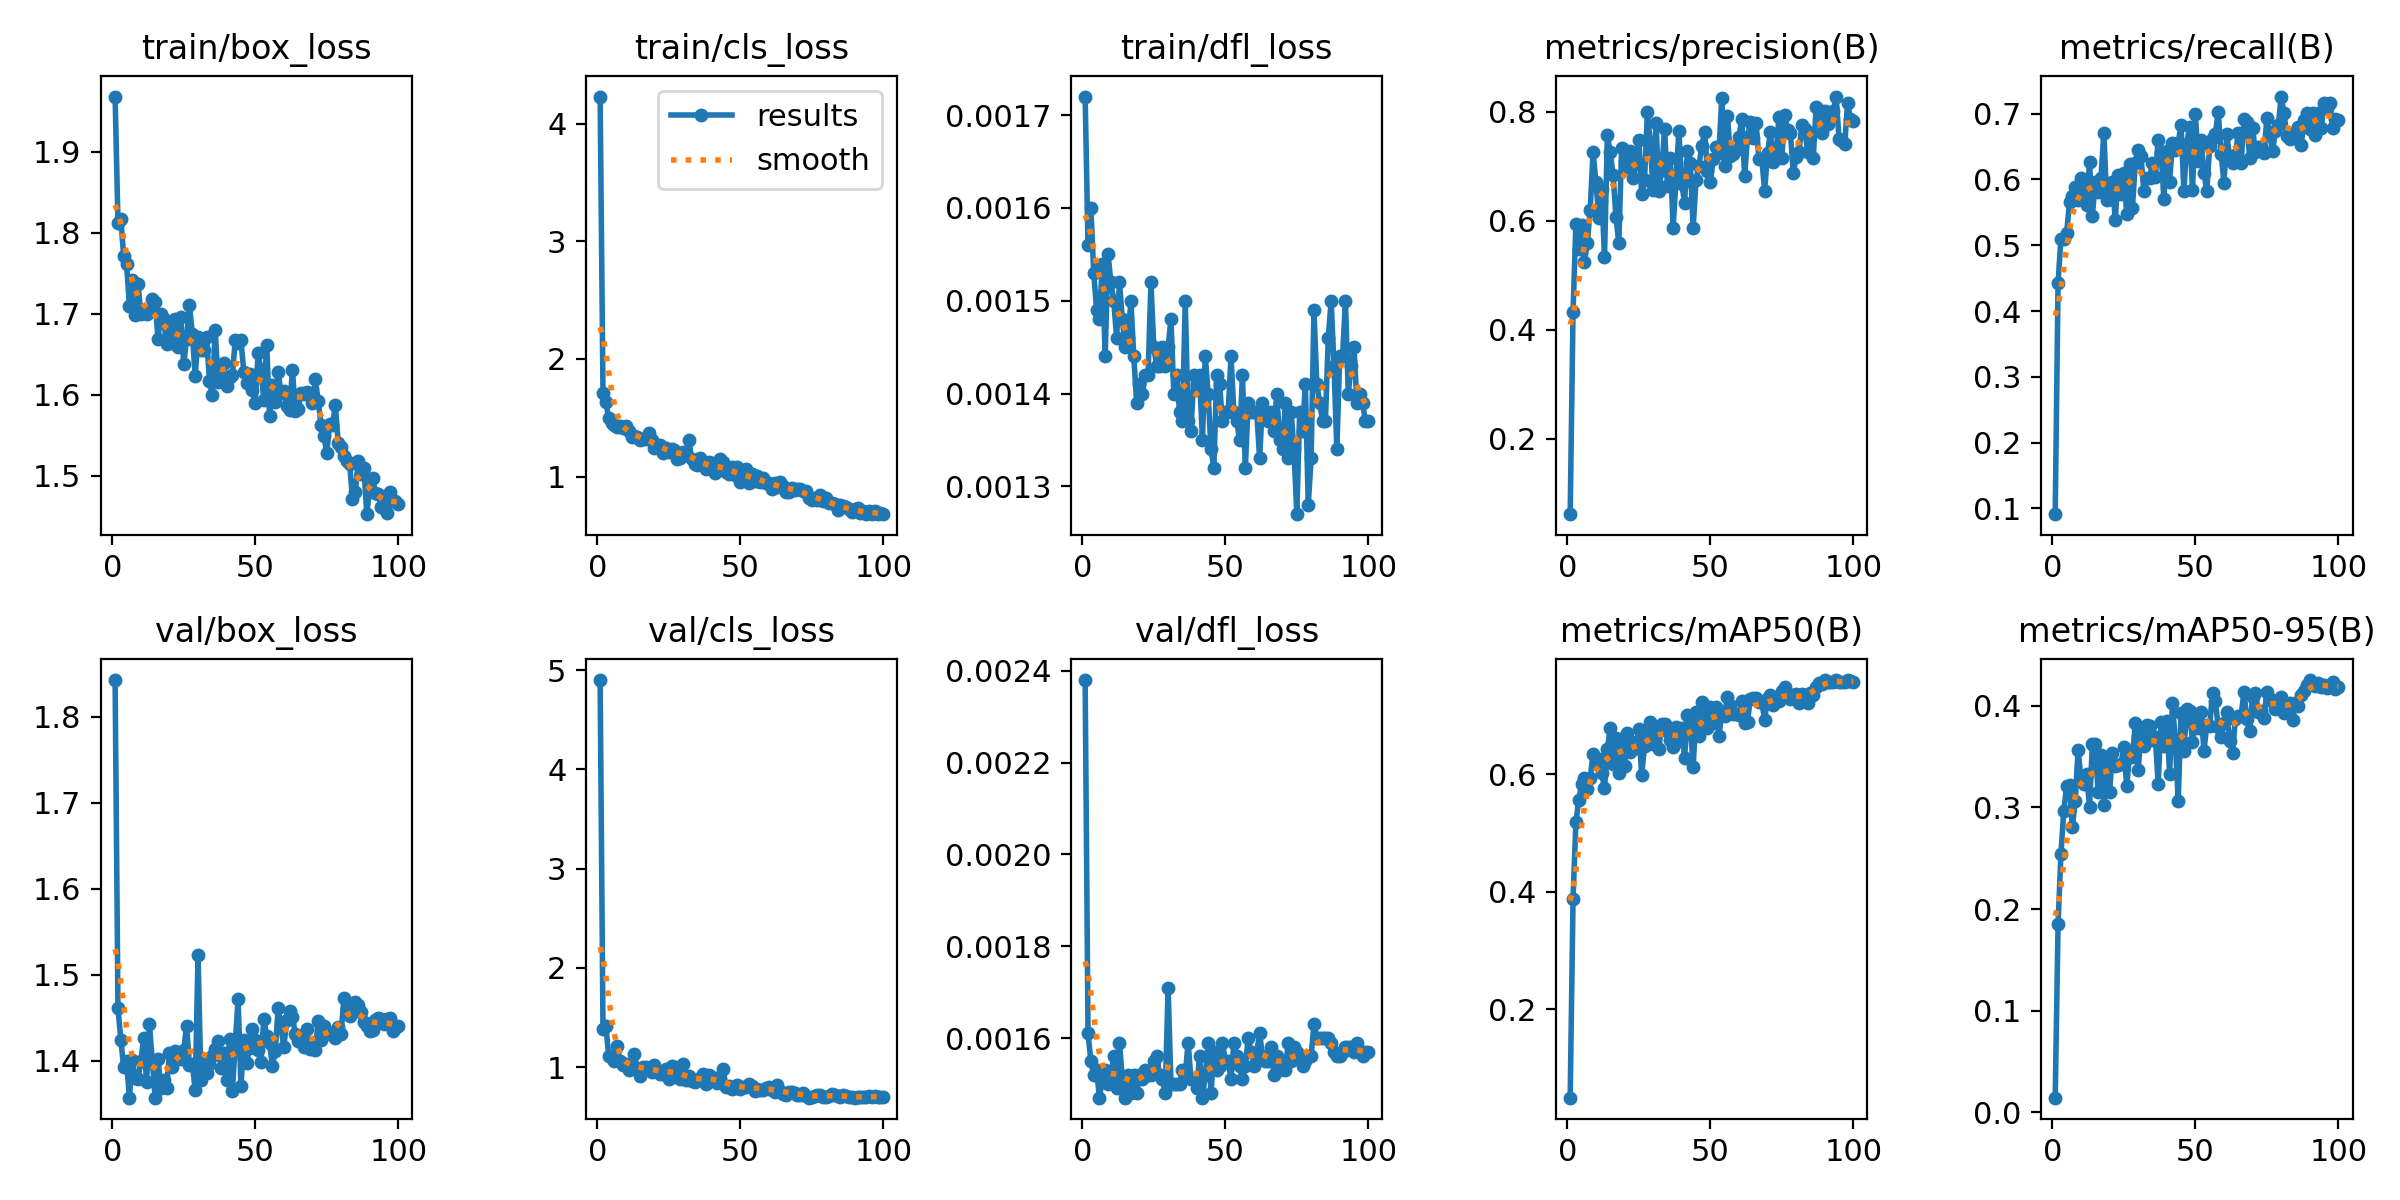

In [30]:
from IPython.display import Image as IPyImage

IPyImage(filename='/kaggle/working/runs/detect/train6/results.png', width=1000)

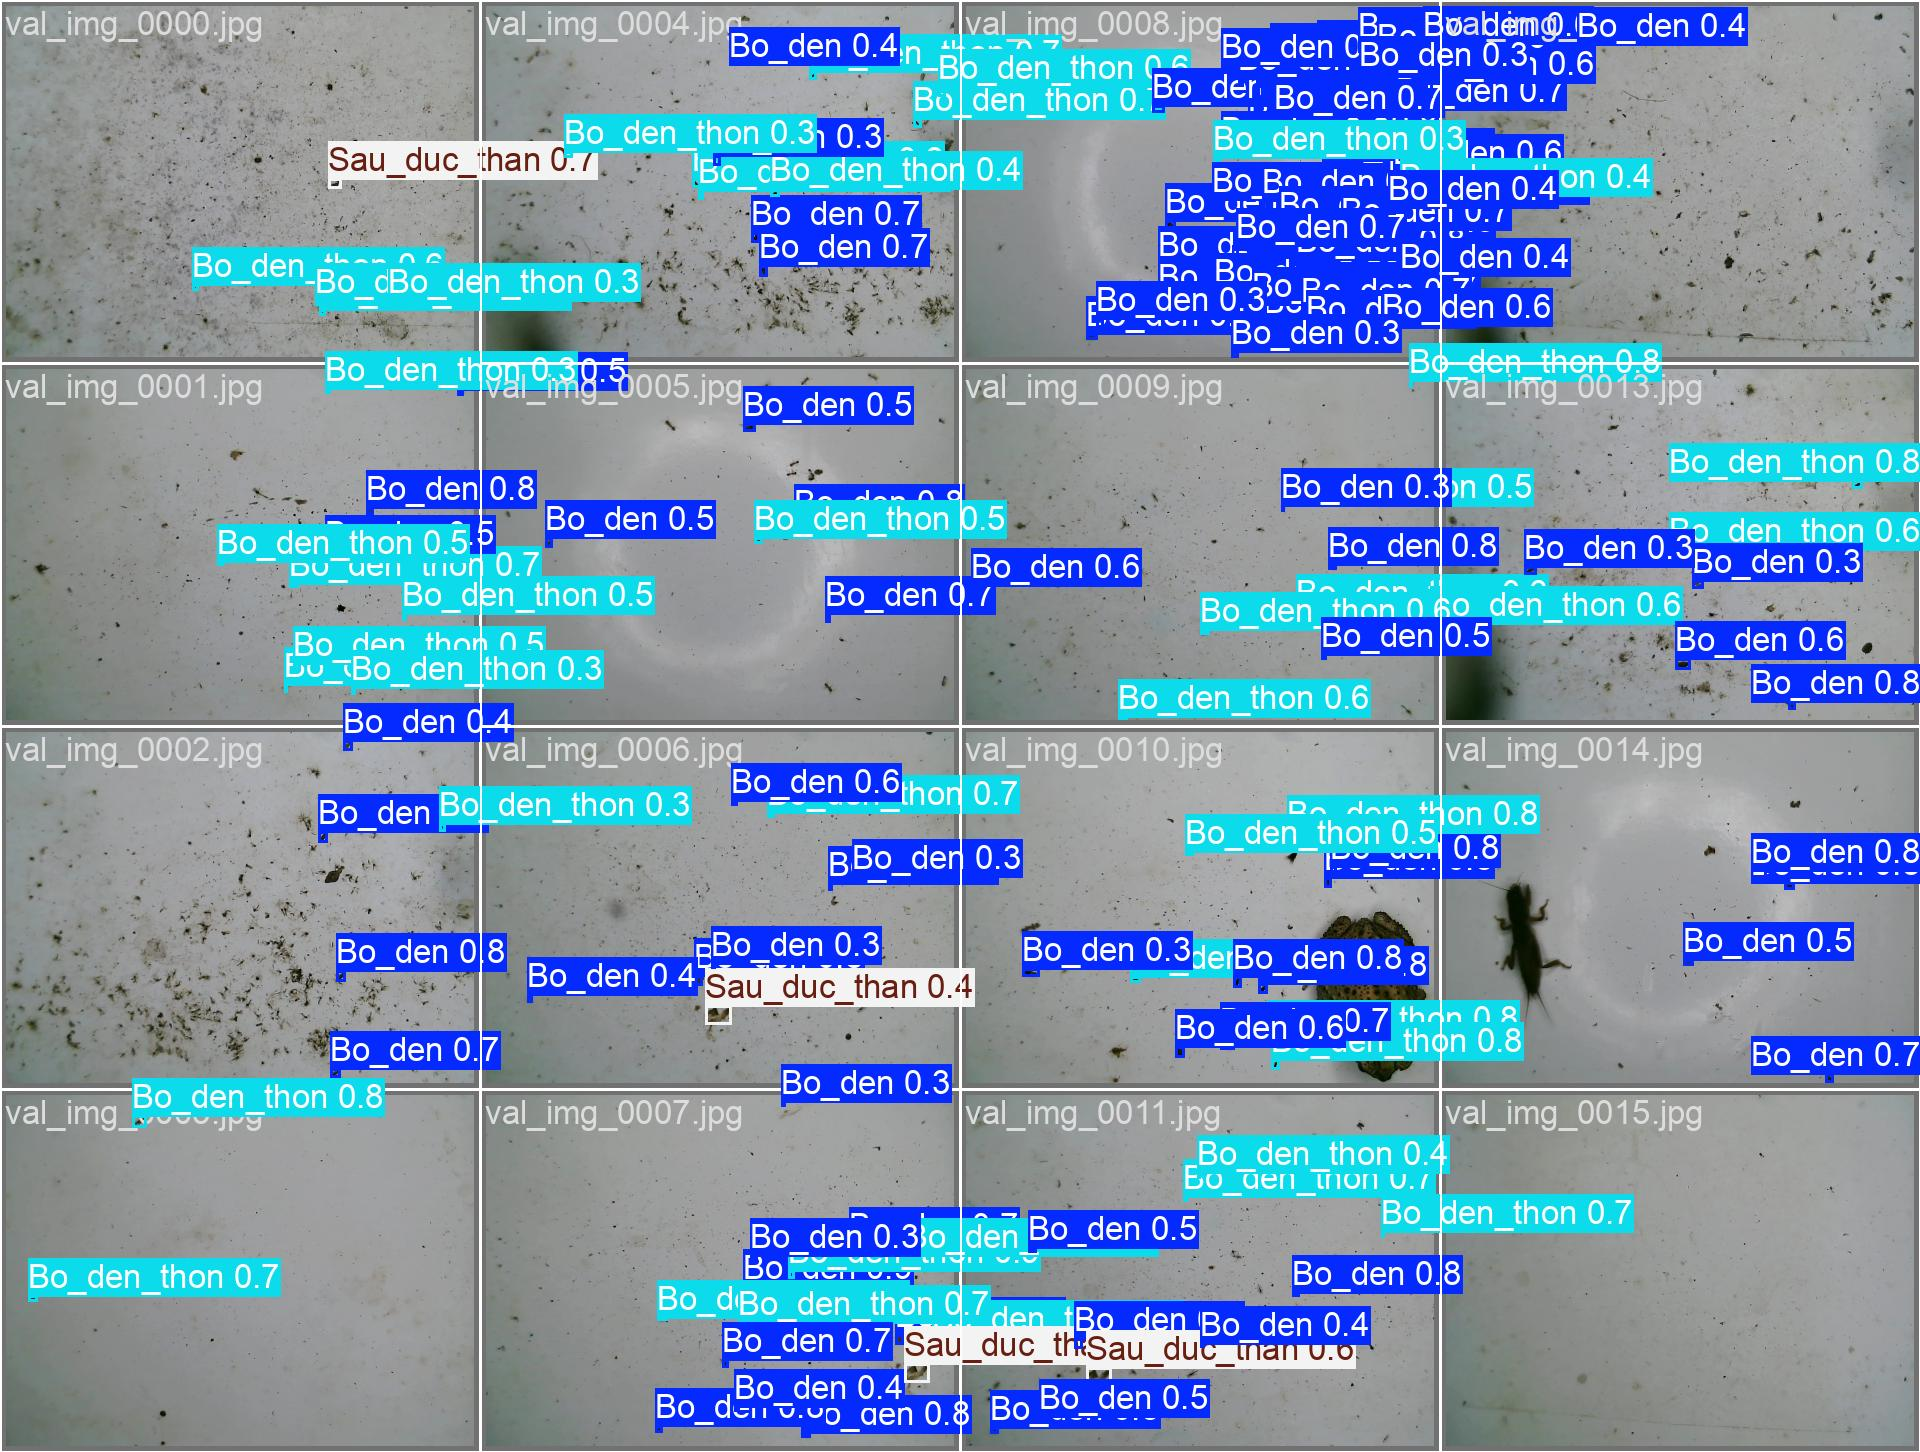

In [34]:
from IPython.display import Image as IPyImage

IPyImage(filename='/kaggle/working/runs/detect/train6/val_batch0_labels.jpg', width=1000)




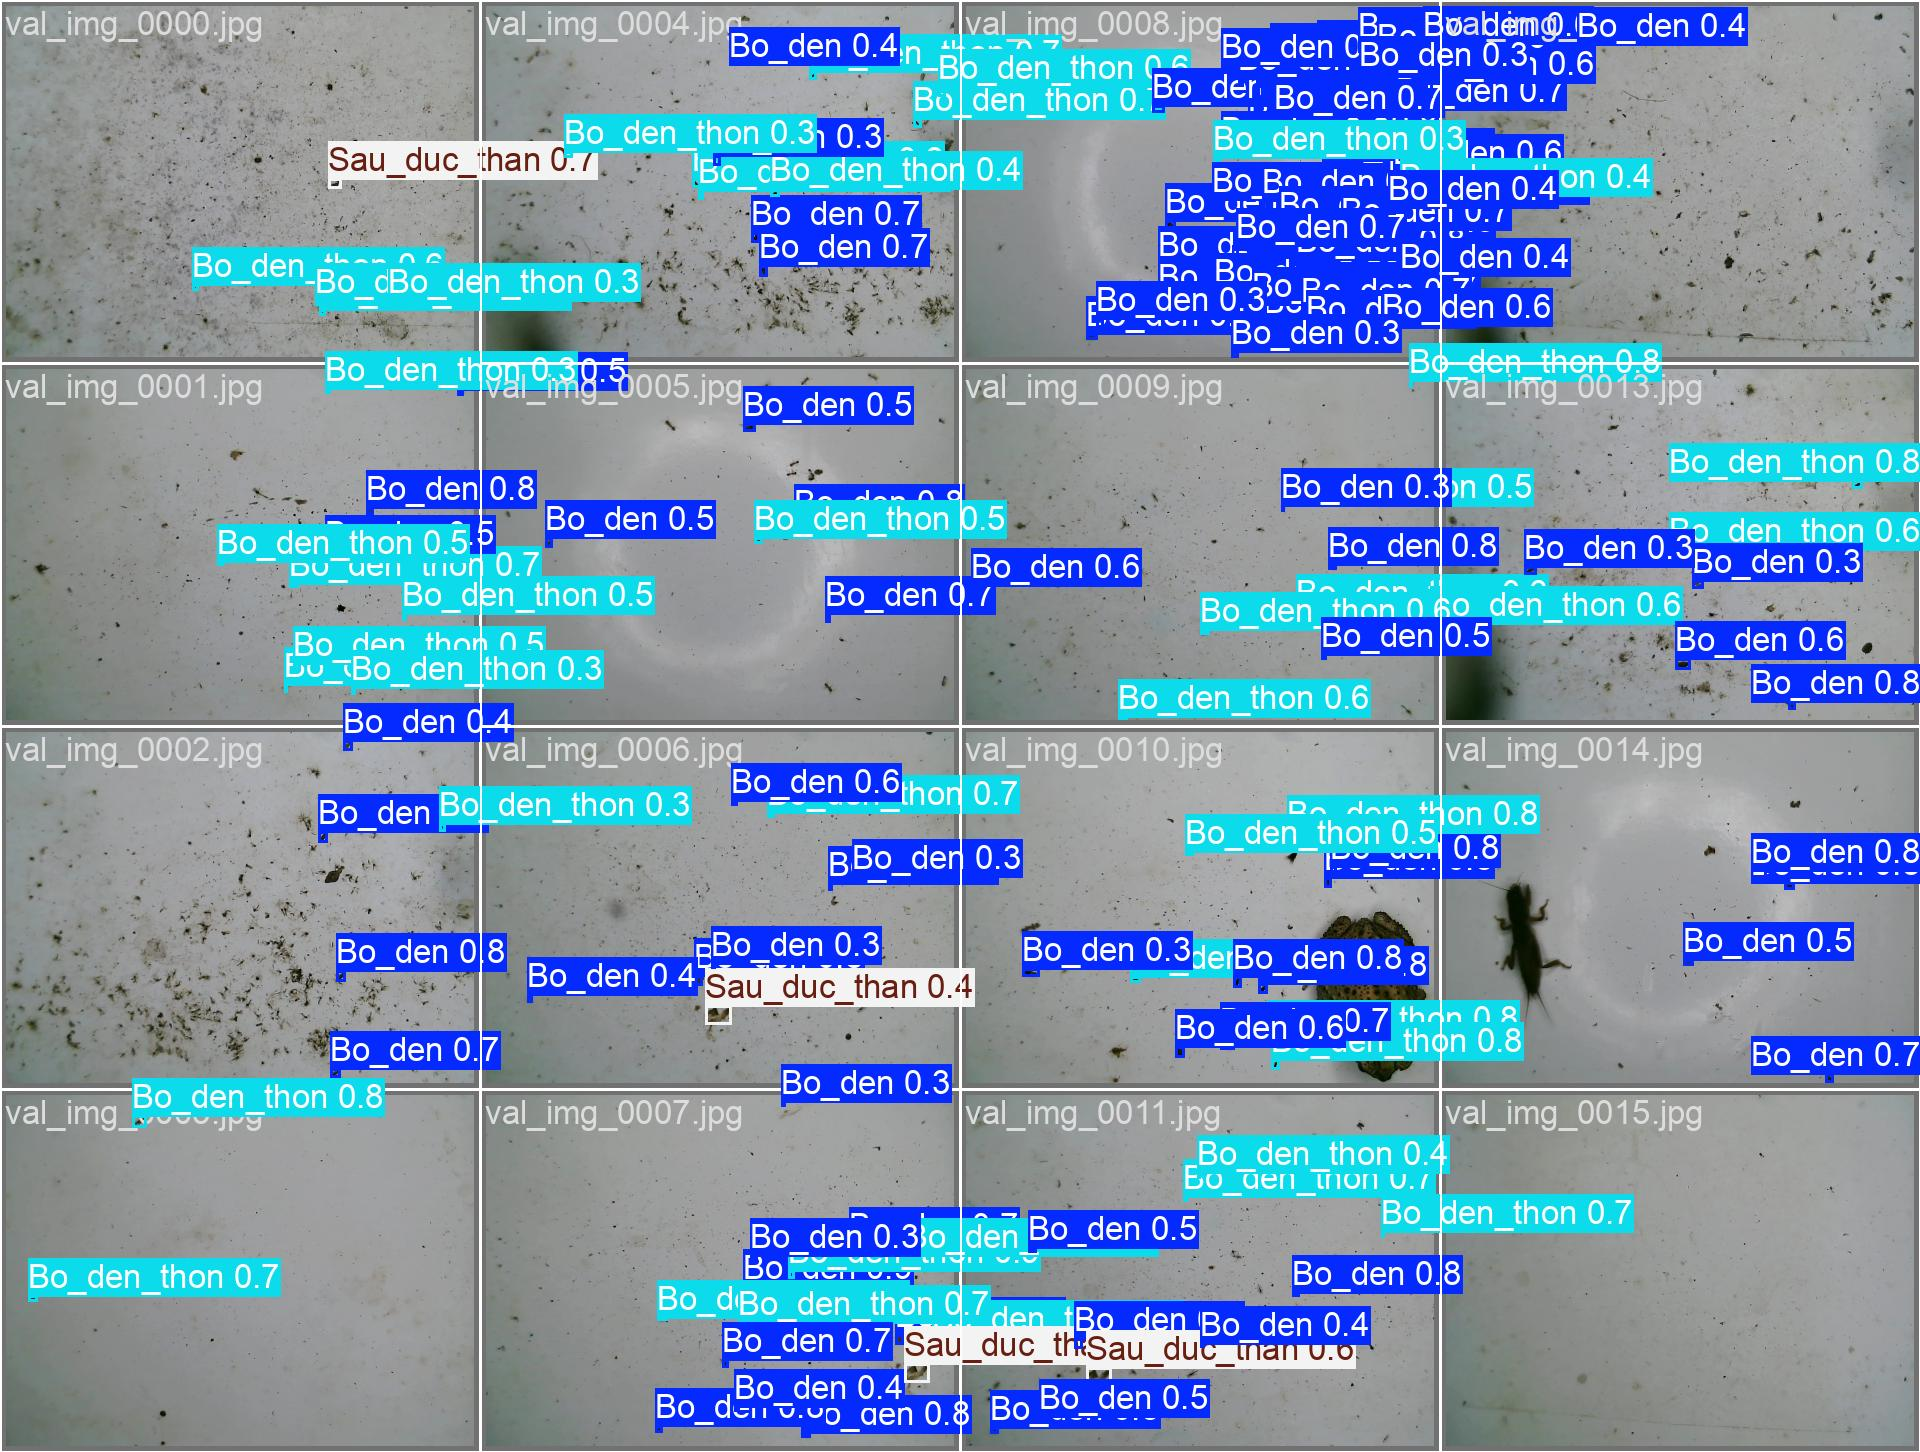

In [35]:
IPyImage(filename='/kaggle/working/runs/detect/train6/val_batch0_pred.jpg', width=1000)

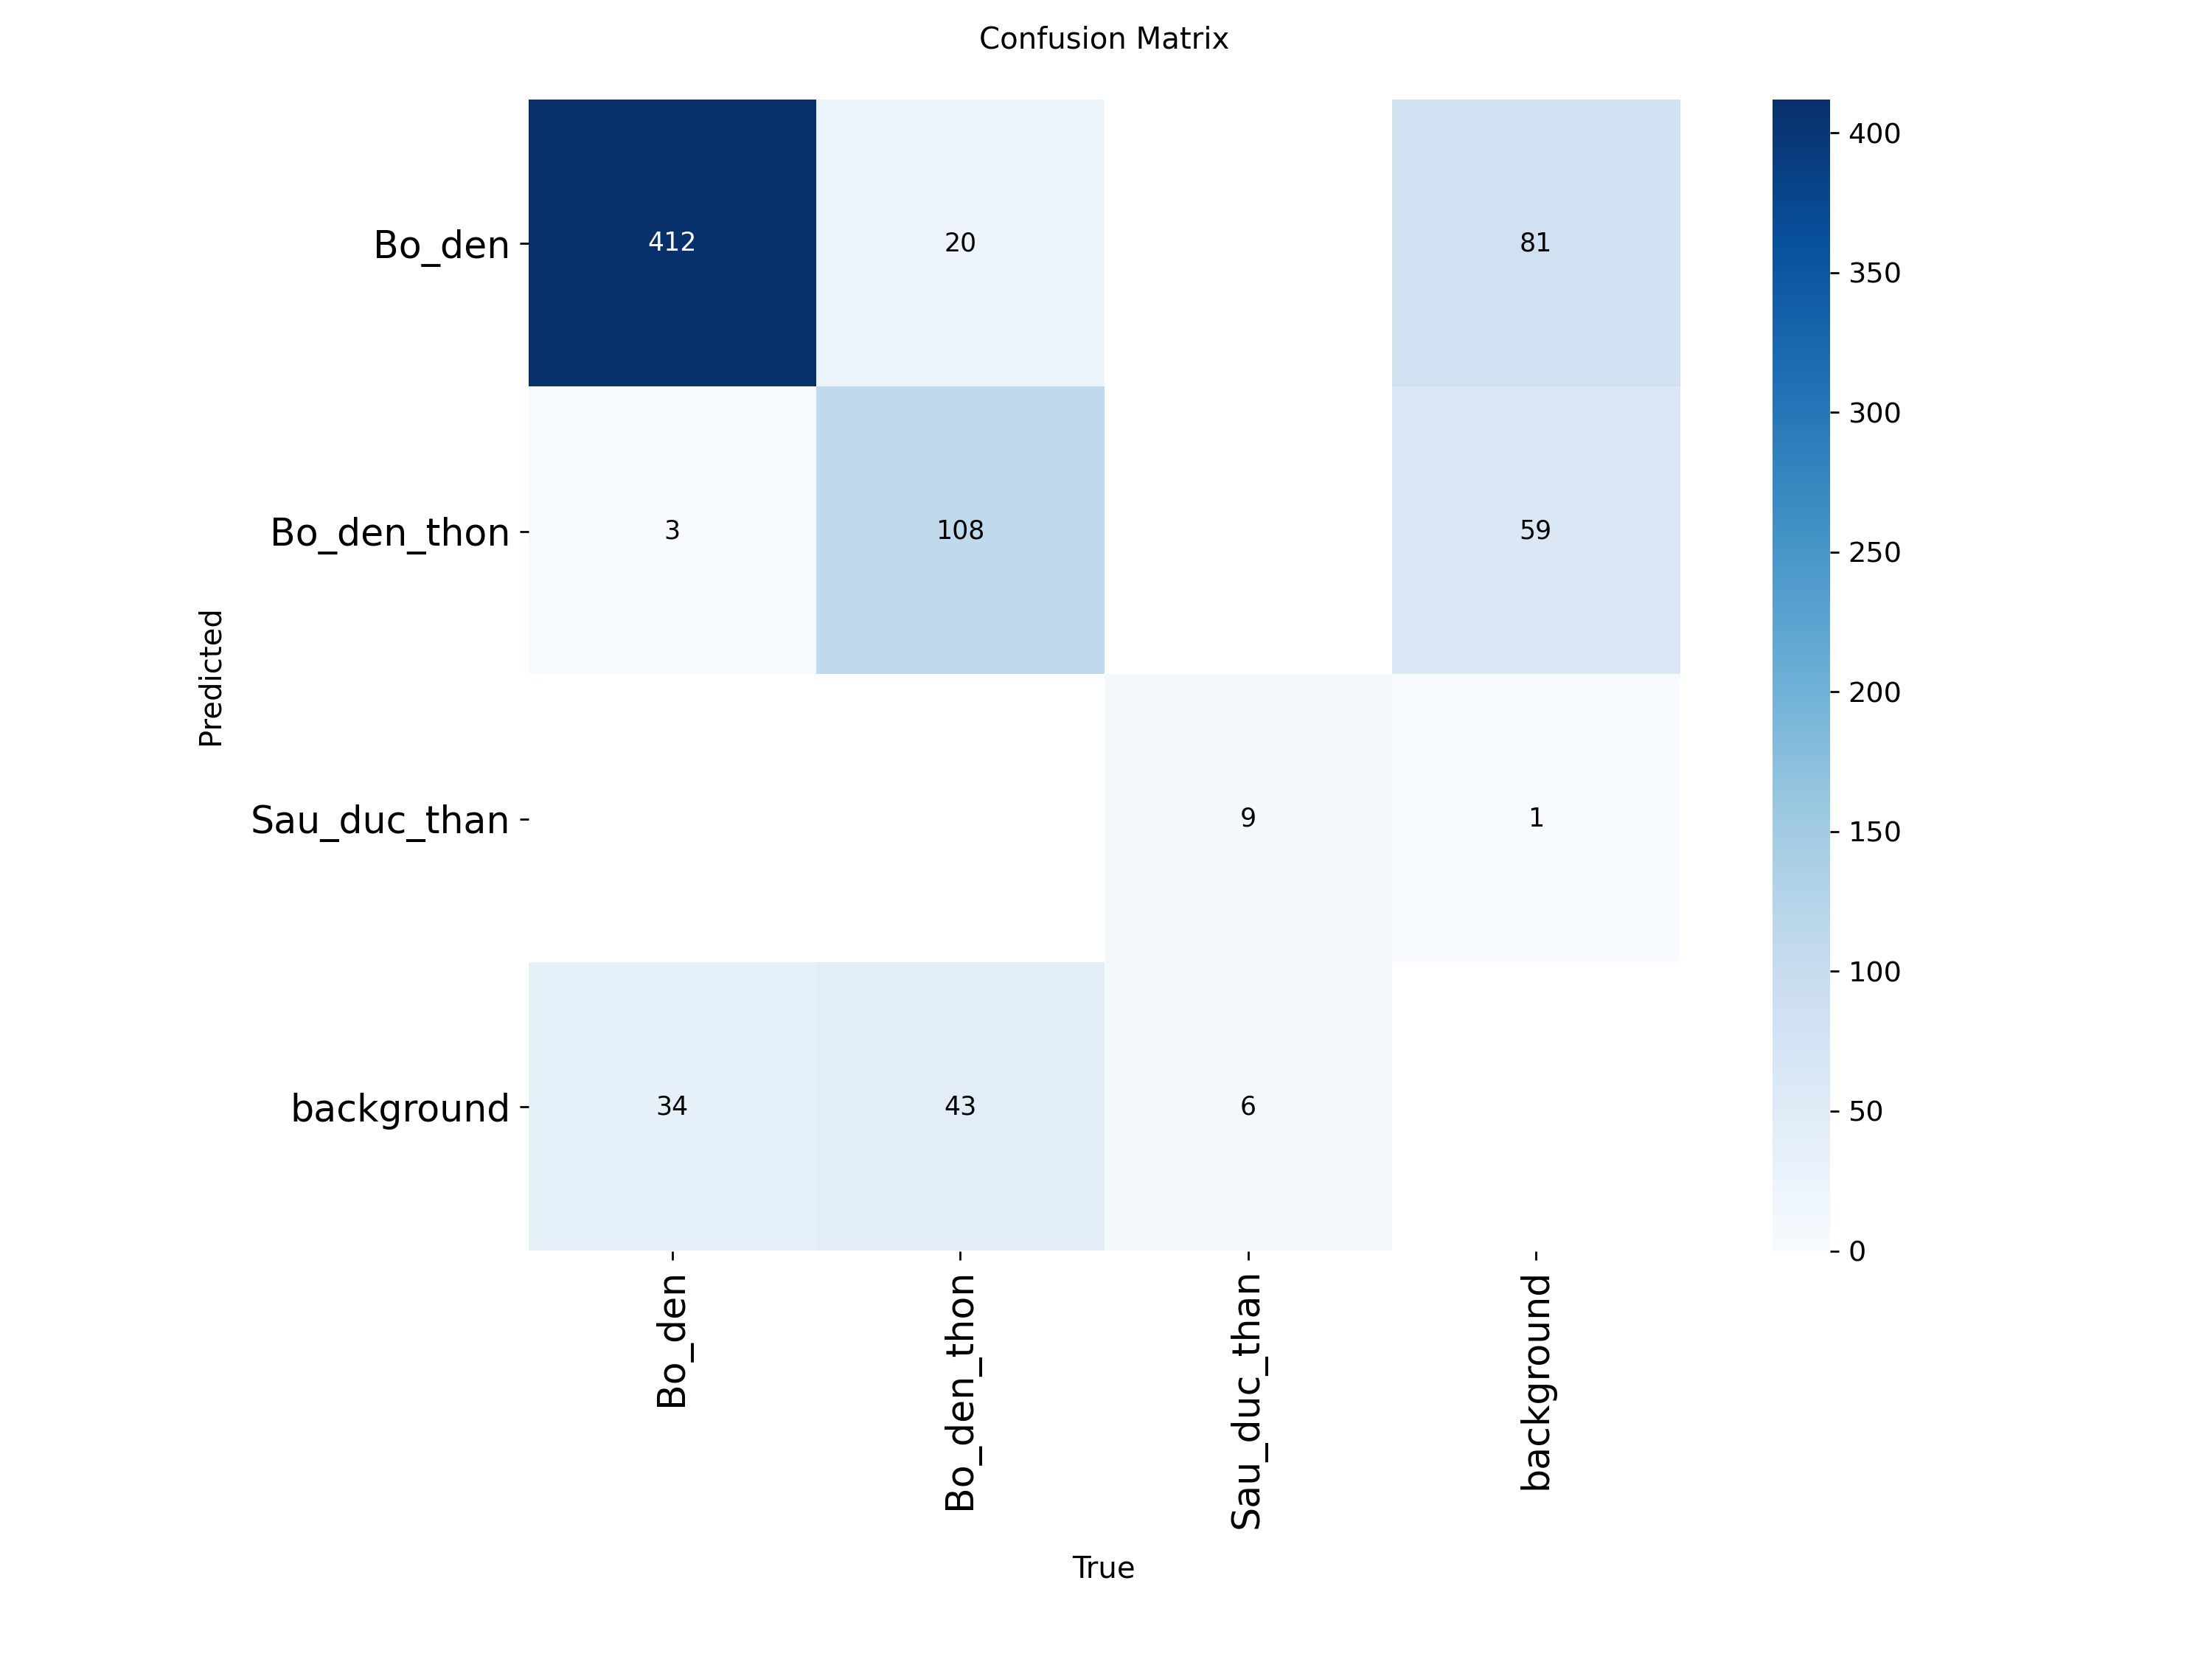

In [37]:
IPyImage(filename='/kaggle/working/runs/detect/train6/confusion_matrix.png', width=1000)